# Librerias

In [5]:
#Librerias requeridas
import numpy as np
import pandas as pd
import sys, os, warnings, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint, uniform
import joblib
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from pandas.api.types import CategoricalDtype
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

warnings.filterwarnings("ignore")

# EDA

In [6]:
# === Celda 1: Imports básicos y configuración ===

RANDOM_STATE = 42  # según la rúbrica
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print("Random state fijado en:", RANDOM_STATE)

# === Celda 1.2: Rutas y carga de datos ===
# Ajusta el nombre de la carpeta si tu estructura difiere
PROJ_ROOT = Path().resolve()        # raíz del repo (VS Code toma el cwd del notebook)
DATA_DIR  = PROJ_ROOT / "Datos_crudos"

clf_path = DATA_DIR / "wine_data_train_classification.csv"
assert clf_path.exists(), f"No se encontró el archivo: {clf_path}"

df = pd.read_csv(clf_path)
print("Archivo cargado desde:", clf_path)
df.shape

Python: 3.11.9
Pandas: 2.3.3
Random state fijado en: 42
Archivo cargado desde: C:\Users\juanc\OneDrive\Documentos\GitHub\Aprendizaje_Automatico_Lab_1\Datos_crudos\wine_data_train_classification.csv


(5847, 14)

In [7]:
# === Celda 3: Vista rápida del dataset ===
display(df.head(10))     # primeras filas
df.tail(3)               # últimas filas (vista rápida)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,quality_category,quality_label
0,6.4000,0.3100,0.2600,13.2000,0.0460,57.0000,205.0000,0.9975,3.1700,0.4100,9.6000,white,Medium,2
1,6.6000,0.2900,0.3100,3.9000,0.0270,39.0000,96.0000,0.9903,3.2400,0.6000,12.6000,white,High,0
2,6.8000,0.3000,0.2300,4.6000,0.0610,50.5000,238.5000,0.9958,3.3200,0.6000,9.5000,white,Medium,2
3,6.6000,0.2500,0.3500,14.0000,0.0690,42.0000,163.0000,0.9990,3.5600,0.4700,9.8000,white,Medium,2
4,7.5000,0.2400,0.3100,13.1000,0.0500,26.0000,180.0000,0.9988,3.0500,0.5300,9.1000,white,Medium,2
5,6.7000,0.3700,0.4100,6.3000,0.0610,22.0000,149.0000,0.9953,3.1600,0.4700,9.6000,white,Medium,2
6,9.8000,0.9800,0.3200,2.3000,0.0780,35.0000,152.0000,0.9980,3.2500,0.4800,9.4000,red,Medium,2
7,5.0000,0.3100,0.0000,6.4000,0.0460,43.0000,166.0000,0.9940,3.3000,0.6300,9.9000,white,Medium,2
8,6.3000,0.2200,0.2800,2.4000,0.0420,38.0000,102.0000,0.9900,3.1400,0.3700,11.6000,white,High,0
9,7.1000,0.3100,0.3000,2.2000,0.0530,36.0000,127.0000,0.9965,2.9400,1.6200,9.5000,red,Medium,2


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,quality_category,quality_label
5844,10.6000,0.8300,0.3700,2.6000,0.0860,26.0000,70.0000,0.9981,3.1600,0.5200,9.9000,red,Medium,2
5845,6.9000,0.3600,0.3500,8.6000,0.0380,37.0000,125.0000,0.9916,3.0000,0.3200,12.4000,white,High,0
5846,7.0000,0.3100,0.3900,7.5000,0.0550,42.0000,218.0000,0.9965,3.3700,0.5400,10.3000,white,Medium,2


In [8]:
# === Celda 4: Info general y tipos ===
df.info()
# === Celda 5: Resumen estadístico (numéricas) ===
desc = df.describe().T
display(desc)
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5847 non-null   float64
 1   volatile acidity      5847 non-null   float64
 2   citric acid           5847 non-null   float64
 3   residual sugar        5847 non-null   float64
 4   chlorides             5847 non-null   float64
 5   free sulfur dioxide   5847 non-null   float64
 6   total sulfur dioxide  5847 non-null   float64
 7   density               5847 non-null   float64
 8   pH                    5847 non-null   float64
 9   sulphates             5847 non-null   float64
 10  alcohol               5847 non-null   float64
 11  type                  5847 non-null   object 
 12  quality_category      5847 non-null   object 
 13  quality_label         5847 non-null   int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 639.6+ KB


,count,mean,std,min,25%,50%,75%,max
fixed acidity,"5,847.0000",7.2186,1.2994,3.8000,6.4000,7.0000,7.7000,15.9000
volatile acidity,"5,847.0000",0.3398,0.1645,0.0800,0.2300,0.2900,0.4000,1.5800
citric acid,"5,847.0000",0.3187,0.1446,0.0000,0.2500,0.3100,0.3900,1.6600
residual sugar,"5,847.0000",5.4654,4.7646,0.6000,1.8000,3.0000,8.2000,65.8000
chlorides,"5,847.0000",0.0561,0.0356,0.0090,0.0380,0.0470,0.0640,0.6110
free sulfur dioxide,"5,847.0000",30.6720,17.8721,1.0000,17.0000,29.0000,42.0000,289.0000
total sulfur dioxide,"5,847.0000",116.2919,56.5065,6.0000,79.0000,119.0000,156.0000,440.0000
density,"5,847.0000",0.9947,0.0030,0.9871,0.9923,0.9949,0.9970,1.0390
pH,"5,847.0000",3.2179,0.1601,2.7200,3.1100,3.2100,3.3200,4.0100
sulphates,"5,847.0000",0.5310,0.1486,0.2200,0.4300,0.5100,0.6000,2.0000


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'type',
 'quality_category',
 'quality_label']

In [9]:
# === Celda 6: Revisión de nulos ===
nulos_abs = df.isna().sum().sort_values(ascending=False)
nulos_pct = (nulos_abs / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"nulos": nulos_abs, "porc(%)": nulos_pct})
display(missing_tbl[missing_tbl["nulos"]>0])

,nulos,porc(%)


In [10]:
# === Celda 7: Columnas clave (target y categórica) ===
# Segun lo que indica la rúbrica:
# - target de clasificación: 'quality_category' (categórica) o 'quality_label' (numérica)
# - variable categórica: 'type' ('red'/'white')
cols = df.columns.tolist()
print("Columnas:", cols)

# Elegimos target numérico para modelar
TARGET = "quality_label"
AUX_CAT = "quality_category"  #para EDA/reportes

# Chequeo básico de target numérico
assert TARGET in df.columns, f"No está {TARGET} en el DataFrame."
vals = sorted(df[TARGET].dropna().unique().tolist())
print("Valores únicos en quality_label:", vals)
assert set(vals).issubset({0,1,2}), "quality_label debe estar en {0,1,2}."

# Distribución de la variable 'type'
if "type" in df.columns:
    print("\nValores únicos de 'type':", df["type"].unique())
    display(df["type"].value_counts().to_frame("conteo"))

# Distribución de clases (target numérico)
dist = df[TARGET].value_counts(dropna=False).sort_index()
dist_pct = (dist/len(df)*100).round(2)
display(pd.DataFrame({"conteo": dist, "porc(%)": dist_pct}).rename(index={0:"High",1:"Medium",2:"Low"}))


Columnas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type', 'quality_category', 'quality_label']
Valores únicos en quality_label: [0, 1, 2]

Valores únicos de 'type': ['white' 'red']


,conteo
type,
white,4421
red,1426


,conteo,porc(%)
quality_label,,
High,1149,19.6500
Medium,222,3.8000
Low,4476,76.5500


Total de variables numéricas analizadas: 11


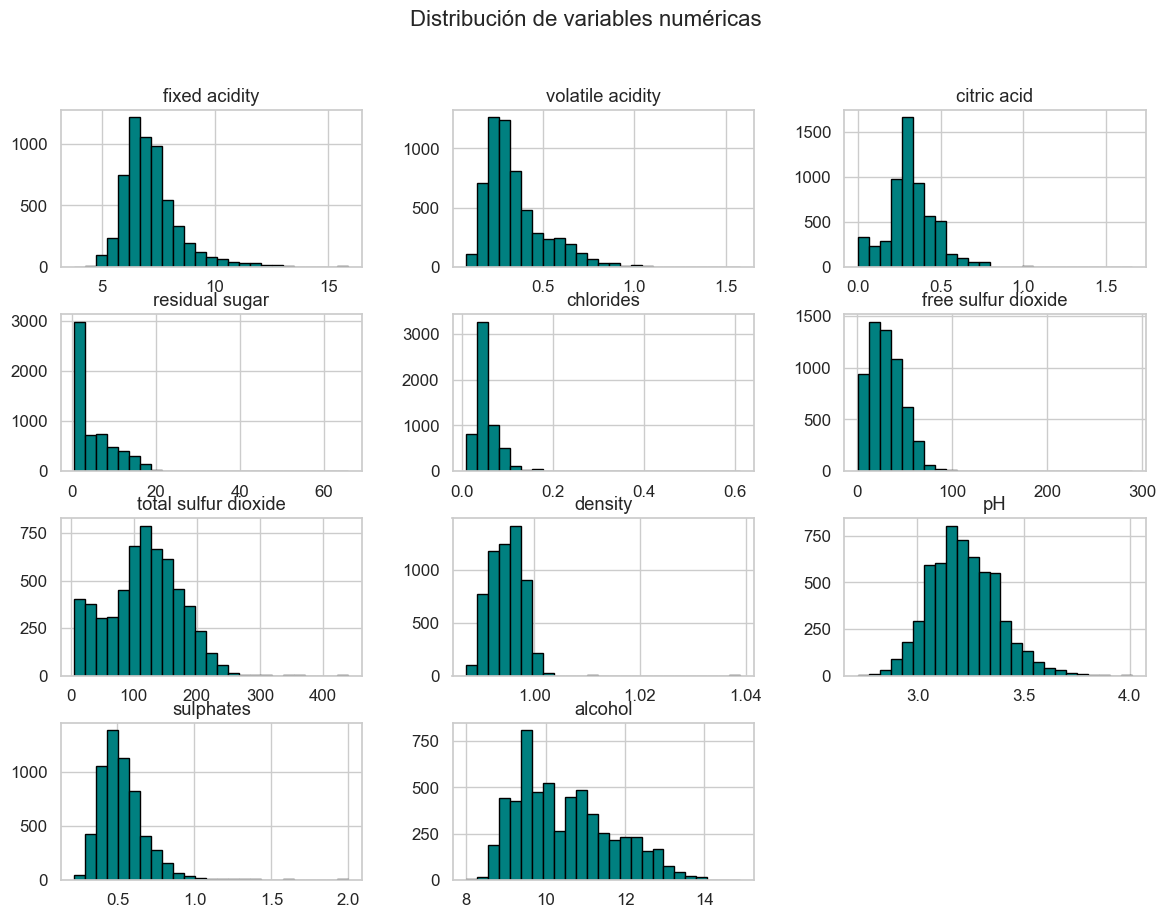

In [11]:
# === Celda 11: EDA inicial (visualización básica) ===

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_cols = [c for c in num_cols if c not in [TARGET]]  # quitamos el target numérico
print(f"Total de variables numéricas analizadas: {len(num_cols)}")

# Histograma general
df[num_cols].hist(figsize=(14,10), bins=25, color='teal', edgecolor='black')
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.show()


## Celda 12: Mapa de correlaciones
+1 → correlación positiva perfecta (aumenta una, aumenta la otra)
-1 → correlación negativa perfecta (aumenta una, disminuye la otra)
0 → no hay relación lineal

array([<Axes: title={'center': 'Matriz de Correlación (Pearson)'}>,
       <Axes: >], dtype=object)

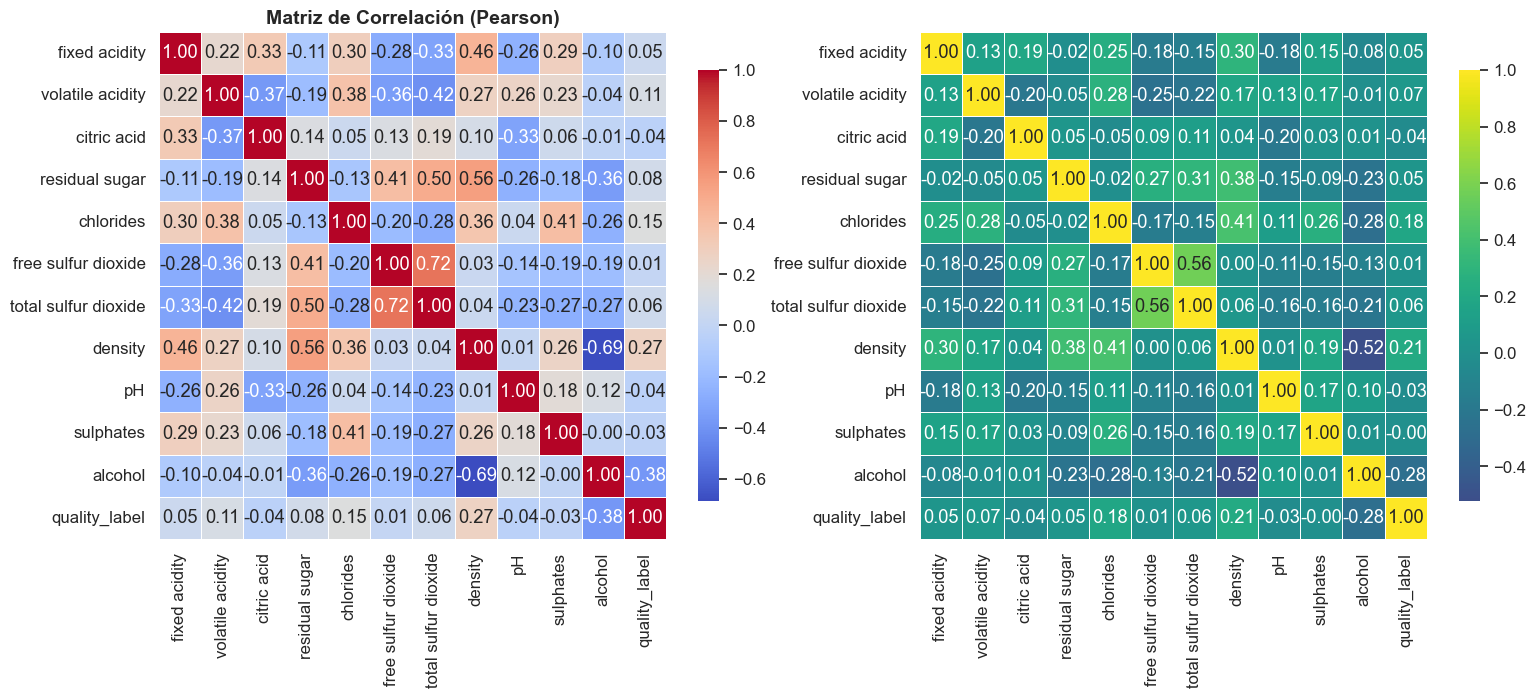

In [12]:
# === Celda 12 (extendida): Mapas de correlaciones (Pearson y Kendall) ===
# Calcular correlaciones
corr_pearson = df[num_cols + [TARGET]].corr(method='pearson')
corr_kendall = df[num_cols + [TARGET]].corr(method='kendall')

# Crear figura con dos heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfica 1: Pearson ---
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", square=True,
    linewidths=0.5,cbar_kws={"shrink": 0.8}, ax=axes[0]
)
axes[0].set_title("Matriz de Correlación (Pearson)", fontsize=14, fontweight='bold')

# --- Gráfica 2: Kendall ---
sns.heatmap(corr_kendall,annot=True, fmt=".2f", cmap="viridis",
    center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1]
)
axes


In [31]:
# === Celda 13: Eliminación de variables con alta correlación (|r| > 0.7) ===
import numpy as np

# 1. Calculamos la matriz de correlación (solo numéricas)
corr_matrix = df[num_cols].corr().abs()

# 2. Tomamos solo la parte superior de la matriz (para evitar duplicados)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Identificamos las columnas con correlación mayor a 0.7
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.7)]

print("Variables con alta correlación (|r| > 0.7):")
print(to_drop)

# 4. Eliminamos esas variables del dataframe
df_reduced = df.drop(columns=to_drop)
print("\nDimensiones antes:", df.shape, " → después:", df_reduced.shape)

# 5. Actualizamos lista de columnas numéricas
num_cols = [c for c in num_cols if c not in to_drop]

# 6. Mostramos la nueva lista de variables numéricas
print("\nColumnas numéricas finales:")
print(num_cols)


Variables con alta correlación (|r| > 0.7):
['total sulfur dioxide']

Dimensiones antes: (5847, 15)  → después: (5847, 14)

Columnas numéricas finales:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


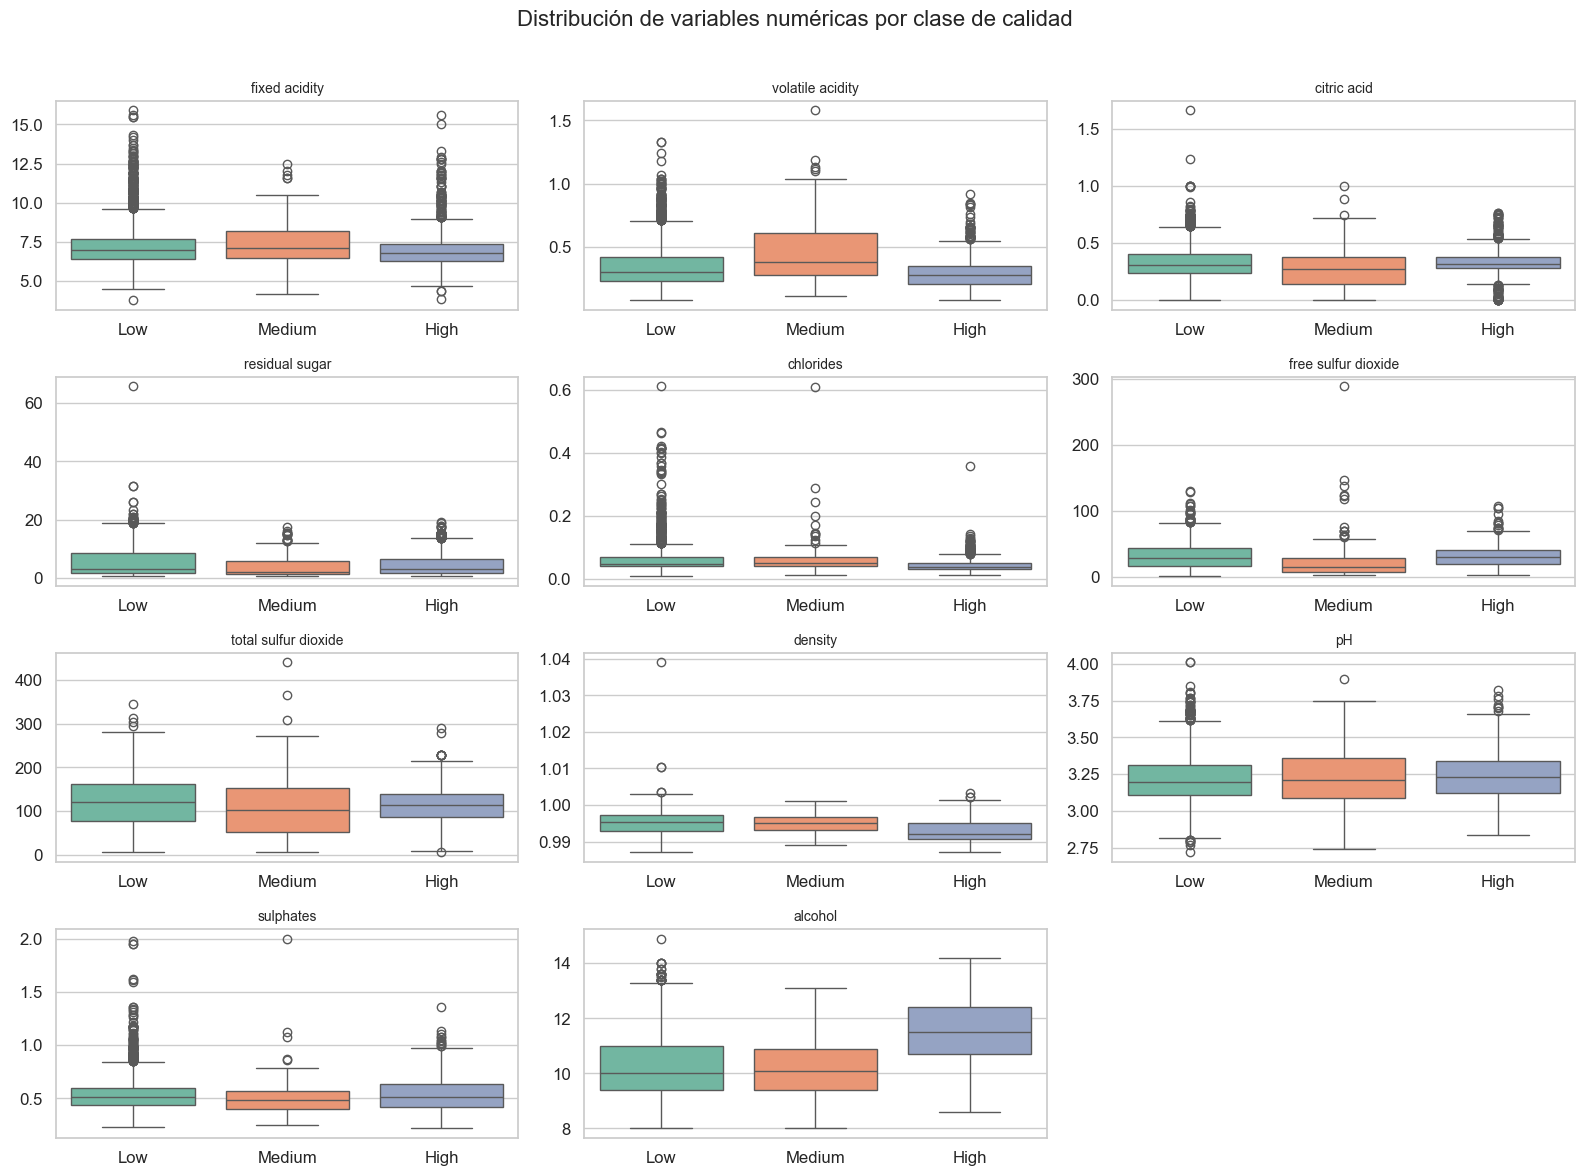

In [13]:
# === Celda 13: Boxplots de variables por clase, Identificación de outliers ===
map_expected = {0: "High", 1: "Medium", 2: "Low"}  # mapeo de la rúbrica
df["quality_from_label"] = df["quality_label"].map(map_expected)

# 2) Orden explícito para el eje X
order_labels = ["Low", "Medium", "High"]
df["quality_from_label"] = df["quality_from_label"].astype(
    CategoricalDtype(categories=order_labels, ordered=True)
)

# 3) Seleccionar columnas numéricas (excluyendo targets/auxiliares)
drop_cols = {"quality_label", "quality_from_label", "quality_category"}
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in drop_cols]

# 4) Graficar (máx 12 variables)
k = min(len(num_cols), 12)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16,12))
axes = axes.flatten()

for i in range(12):
    ax = axes[i]
    if i < k:
        col = num_cols[i]
        sns.boxplot(data=df, x="quality_from_label", y=col, ax=ax, order=order_labels, palette="Set2")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
    else:
        ax.axis("off")

plt.suptitle("Distribución de variables numéricas por clase de calidad", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

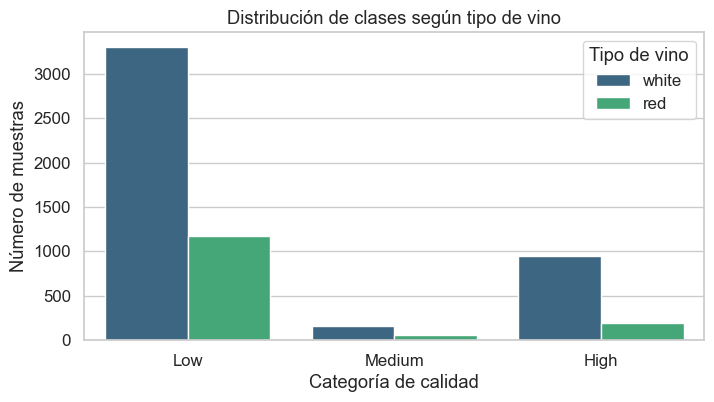

In [14]:
# === Celda 14: Conteo de clases y tipo de vino ===
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="quality_from_label", hue="type", palette="viridis")
plt.title("Distribución de clases según tipo de vino")
plt.xlabel("Categoría de calidad")
plt.ylabel("Número de muestras")
plt.legend(title="Tipo de vino")
plt.show()


En un problema de clasificación multiclase como este:

    -Los modelo a favorece la clase mayoritaria (Low) si no se corrige el desbalance.
    -Podrías tener una alta accuracy simplemente porque el modelo predice casi siempre la clase más común.
    -El F1-score macro y weighted (que la rúbrica exige ≥0.80) penalizan ese comportamiento.

# Entrenamiento de modelos

In [32]:
# === Celda 15 (ajustada): Separación de variables y preprocesamiento ===

# 1️⃣ Elegimos el dataframe ya depurado
# (si quieres seguir llamándolo df, puedes hacer: df = df_reduced)
df_model = df_reduced.copy()

# 2️⃣ Variables predictoras y target
X = df_model.drop(columns=[TARGET, "quality_category", "quality_from_label"], errors="ignore")
y = df_model[TARGET]

# 3️⃣ Identificamos tipos de columnas
cat_cols = ["type"]  # sigue siendo categórica
# OJO: num_cols ya fue depurada en la celda 13, pero la volvemos a cruzar con X por seguridad
num_cols = [c for c in X.columns if c not in cat_cols]

print("Columnas numéricas usadas en el preprocesamiento:")
print(num_cols)

# 4️⃣ Transformaciones
num_transformer = RobustScaler()  # resiste outliers
cat_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")  # evita multicolinealidad

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ],
    remainder="drop"
)

# 5️⃣ División estratificada
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de validación:", X_val.shape)
print("Distribución clases entrenamiento:\n", y_train.value_counts(normalize=True).round(3))
print("Distribución clases validación:\n", y_val.value_counts(normalize=True).round(3))


Columnas numéricas usadas en el preprocesamiento:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Tamaño de entrenamiento: (4677, 11)
Tamaño de validación: (1170, 11)
Distribución clases entrenamiento:
 quality_label
2   0.7650
0   0.1960
1   0.0380
Name: proportion, dtype: float64
Distribución clases validación:
 quality_label
2   0.7660
0   0.1970
1   0.0380
Name: proportion, dtype: float64


## RandomForest

In [ ]:
# === Celda 16 (ajustada): Modelo baseline RandomForest con balanceo (SMOTE) en el pipeline ===
# Unifica todo el flujo (encoding + scaling + balanceo + modelo) en una sola estructura
# Esto evita fugas de datos (data leakage) y mantiene el código limpio


# 1️⃣ Definimos el modelo base
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 2️⃣ Definimos SMOTE (se aplicará SOLO sobre el train dentro del fit)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

# 3️⃣ Armamos el pipeline completo
# preprocessor viene de la Celda 15 y usa num_cols actualizadas
pipe_rf = Pipeline(steps=[
    ("preprocess", preprocessor),  # ColumnTransformer actualizado
    ("smote", smote),              # balanceo de clases
    ("model", rf_clf)              # clasificador
])

# 4️⃣ Entrenamos el modelo
pipe_rf.fit(X_train, y_train)

# 5️⃣ Predicciones sobre el conjunto de validación (NO se balancea)
y_pred = pipe_rf.predict(X_val)

# 6️⃣ Reportes y métricas
print("=== Reporte de clasificación (validación) ===")
print(classification_report(y_val, y_pred))

print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_val, y_pred))



=== Reporte de clasificación (validación) ===
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       230
           1       0.35      0.41      0.38        44
           2       0.90      0.88      0.89       896

    accuracy                           0.83      1170
   macro avg       0.64      0.66      0.65      1170
weighted avg       0.83      0.83      0.83      1170


=== Matriz de confusión ===
[[163   2  65]
 [  2  18  24]
 [ 79  32 785]]


## GridSearchCV 

In [40]:
# === Celda 17: Búsqueda de mejor modelo con GridSearchCV (optimiza F1-macro) ===
from sklearn.model_selection import GridSearchCV

# Partimos del pipeline que ya creaste en la Celda 16: pipe_rf
# Ese pipeline tiene: preprocess -> SMOTE -> RandomForest

# Definimos el espacio de búsqueda
param_grid = {
    "model__max_depth": [4, 6, 8, 10, 12, 14, None],
    "model__min_samples_leaf": [1, 2, 3, 4, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__n_estimators": [200, 300, 400, 600],
    "model__class_weight": [None, "balanced"]
}

# Configuramos el GridSearch
grid = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid,
    cv=5,                      # 5 folds estratificados por default para clasificación
    scoring="f1_macro",        # lo que pide la rúbrica
    n_jobs=-1,                 # usar todos los núcleos
    verbose=2
)

# Entrenamos la búsqueda
grid.fit(X_train, y_train)

print("=== Mejor puntaje (CV, f1_macro) ===")
print(grid.best_score_.round(4))

print("\n=== Mejores hiperparámetros encontrados ===")
print(grid.best_params_)

# Usamos el mejor modelo encontrado para predecir en el set de validación
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_val)

from sklearn.metrics import classification_report, confusion_matrix

print("\n=== Desempeño en VALIDACIÓN con el mejor modelo ===")
print(classification_report(y_val, y_pred_best))

print("=== Matriz de confusión (mejor modelo) ===")
print(confusion_matrix(y_val, y_pred_best))


Fitting 5 folds for each of 1568 candidates, totalling 7840 fits
=== Mejor puntaje (CV, f1_macro) ===
0.6049

=== Mejores hiperparámetros encontrados ===
{'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

=== Desempeño en VALIDACIÓN con el mejor modelo ===
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       230
           1       0.34      0.39      0.36        44
           2       0.90      0.87      0.88       896

    accuracy                           0.82      1170
   macro avg       0.63      0.65      0.64      1170
weighted avg       0.83      0.82      0.82      1170

=== Matriz de confusión (mejor modelo) ===
[[162   2  66]
 [  2  17  25]
 [ 82  31 783]]


##  XGBoost

In [39]:
# === Celda 18: XGBoost multiclase con sample_weight y tuning de hiperparámetros ===

# 1️⃣ Calculamos los pesos por clase (inverso a la frecuencia)
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
cw_map = {cls: w for cls, w in zip(classes, class_weights)}

# Vector de pesos por fila (para pasar al modelo)
sample_weight_train = y_train.map(cw_map).values

# 2️⃣ Definimos el pipeline: preprocesamiento + modelo XGBoost
xgb_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# 3️⃣ Definimos la grilla de búsqueda (tuning)
param_grid = {
    "model__max_depth": [4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

# 4️⃣ Configuramos la búsqueda (optimiza F1-macro)
grid_xgb = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 5️⃣ Entrenamos (con sample_weight)
grid_xgb.fit(X_train, y_train, **{"model__sample_weight": sample_weight_train})

# 6️⃣ Resultados del tuning
print("=== Mejores hiperparámetros encontrados ===")
print(grid_xgb.best_params_)

print("\n=== Mejor puntaje medio (CV, f1_macro) ===")
print(grid_xgb.best_score_.round(4))

# 7️⃣ Evaluación final sobre el conjunto de validación
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)

acc_xgb = accuracy_score(y_val, y_pred_xgb)
f1m_xgb = f1_score(y_val, y_pred_xgb, average="macro")
f1w_xgb = f1_score(y_val, y_pred_xgb, average="weighted")

print("\n=== Desempeño en VALIDACIÓN con el mejor modelo XGBoost ===")
print(f"[XGB + tuning] Accuracy    : {acc_xgb:.3f}")
print(f"[XGB + tuning] F1-macro    : {f1m_xgb:.3f}")
print(f"[XGB + tuning] F1-weighted : {f1w_xgb:.3f}")

print("\nClassification Report:\n", classification_report(y_val, y_pred_xgb))
print("Matriz de Confusión:\n", confusion_matrix(y_val, y_pred_xgb))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
=== Mejores hiperparámetros encontrados ===
{'model__learning_rate': 0.01, 'model__max_depth': 10, 'model__subsample': 0.9}

=== Mejor puntaje medio (CV, f1_macro) ===
0.6048

=== Desempeño en VALIDACIÓN con el mejor modelo XGBoost ===
[XGB + tuning] Accuracy    : 0.823
[XGB + tuning] F1-macro    : 0.643
[XGB + tuning] F1-weighted : 0.823

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.72      0.67       230
           1       0.47      0.32      0.38        44
           2       0.90      0.88      0.89       896

    accuracy                           0.82      1170
   macro avg       0.66      0.64      0.64      1170
weighted avg       0.83      0.82      0.82      1170

Matriz de Confusión:
 [[165   2  63]
 [  2  14  28]
 [ 98  14 784]]


In [43]:
# === Celda 20: elegir el mejor umbral encontrado ===

# usamos las mismas probabilidades que ya calculaste en la celda 19
proba = model_threshold.predict_proba(X_val)

umbrales = np.arange(0.2, 0.6, 0.05)
mejor_umbral = None
mejor_f1m = -1
mejor_pred = None

for t in umbrales:
    y_pred_t = np.where(proba[:, 1] > t, 1, np.argmax(proba, axis=1))
    f1m = f1_score(y_val, y_pred_t, average="macro")
    if f1m > mejor_f1m:
        mejor_f1m = f1m
        mejor_umbral = t
        mejor_pred = y_pred_t

acc = accuracy_score(y_val, mejor_pred)
f1w = f1_score(y_val, mejor_pred, average="weighted")

print(f"=== Mejor umbral encontrado ===")
print(f"Umbral óptimo para clase 1: {mejor_umbral:.2f}")
print(f"F1-macro: {mejor_f1m:.3f}")
print(f"Accuracy: {acc:.3f}")
print(f"F1-weighted: {f1w:.3f}\n")

print("Classification report (umbral óptimo):\n", classification_report(y_val, mejor_pred))
print("Matriz de confusión (umbral óptimo):\n", confusion_matrix(y_val, mejor_pred))



=== Mejor umbral encontrado ===
Umbral óptimo para clase 1: 0.20
F1-macro: 0.650
Accuracy: 0.799
F1-weighted: 0.810

Classification report (umbral óptimo):
               precision    recall  f1-score   support

           0       0.62      0.72      0.67       230
           1       0.31      0.61      0.42        44
           2       0.91      0.83      0.87       896

    accuracy                           0.80      1170
   macro avg       0.62      0.72      0.65      1170
weighted avg       0.83      0.80      0.81      1170

Matriz de confusión (umbral óptimo):
 [[165   4  61]
 [  1  27  16]
 [ 98  55 743]]


In [44]:
# === Celda 20: Validación cruzada comparativa (RF baseline, RF tuned, XGBoost tuned) ===
from sklearn.model_selection import cross_val_score
import numpy as np

# Pipelines finales (ajústalos según tus variables)
modelos = {
    "RF + SMOTE (baseline)": pipe_rf,
    "RF + GridSearch (tuned)": grid.best_estimator_,
    "XGBoost + tuning": best_xgb
}

print("=== Validación cruzada (5 folds) — Métrica: F1-macro ===")
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring="f1_macro", n_jobs=-1)
    print(f"\nModelo: {nombre}")
    print(f"F1-macro promedio : {scores.mean():.4f}")
    print(f"Desviación estándar: {scores.std():.4f}")


=== Validación cruzada (5 folds) — Métrica: F1-macro ===

Modelo: RF + SMOTE (baseline)
F1-macro promedio : 0.6235
Desviación estándar: 0.0110

Modelo: RF + GridSearch (tuned)
F1-macro promedio : 0.6301
Desviación estándar: 0.0103

Modelo: XGBoost + tuning
F1-macro promedio : 0.5746
Desviación estándar: 0.0124


# Guardar mejor modelo

In [69]:
# === Celda 22: Guardar el mejor modelo ===

OUT_MODELS = PROJ_ROOT / "modelos"
OUT_MODELS.mkdir(exist_ok=True)

out_path = OUT_MODELS / "modelo_clasificacion_vino.pkl"
joblib.dump(best_model, out_path)
print("Modelo guardado en:", out_path)


Modelo guardado en: C:\Users\juanc\OneDrive\Documentos\GitHub\Aprendizaje_Automatico_Lab_1\modelos\modelo_clasificacion_vino.pkl
